In [2]:
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import time

import torchvision
from torch.utils import data
from torchvision import transforms
from IPython import display

In [5]:
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=False
)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=False
)

In [6]:
# 读取数据
def get_fashion_mnist_labels(labels):
    """返回Fashion-MNIST数据集的文本标签"""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """绘制图像列表"""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # 图片张量
            ax.imshow(img.numpy())
        else:
            # PIL图片
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

def get_dataloader_workers():  #@save
    """使用4个进程来读取数据"""
    return 4

def load_data_fashion_mnist(batch_size, resize=None):  #@save
    """下载Fashion-MNIST数据集，然后将其加载到内存中"""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=get_dataloader_workers()))

In [ ]:
# 模型
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdim=True)
    return X_exp / partition

def net(X):
    return softmax(X.reshape(-1, W.shape[0]) @ W + b)

def cross_entropy(y_hat, y):    # y为标签序号，非one-hot
    return -torch.log(y_hat[range(len(y_hat)), y])

def accuracy(y_hat, y):     # 正确预测的数量
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1: # y_hat为矩阵
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy(net, data_iter): 
    """计算指定数据集上模型的精度"""
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]




def train_epoch(net, train_iter, loss, updater):    # 一个训练周期
    metric = Accumulator(3) # 训练损失总和、训练准确度总和、样本数
    for X, y in train_iter:
        y_hat = net(X)
        l = loss(y_hat, y)
        l.sum().backward()
        updater(X.shape[0])

        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    # 返回训练损失和训练精度
    return metric[0] / metric[2], metric[1] / metric[2]


def train(net, train_iter, test_iter, loss, num_epochs, updater):  #训练模型
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)

        train_loss, train_acc = train_metrics
        print(f'epoch: {epoch}, train_loss: {train_loss: .6f}, train_acc: {train_acc: .4f}, test_acc: {test_acc: .4f}')
        
        animator.add(epoch + 1, train_metrics + (test_acc,))
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc

def predict(net, test_iter, n=6):
    for X, y in test_iter:
        break
    trues = get_fashion_mnist_labels(y)
    preds = get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true + '\n' + pred for true, pred in zip(trues, preds)]
    show_images(X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])



def updater(batch_size):
    return sgd([W, b], lr, batch_size)

def sgd(params, lr, batch_size):
    # 小批量随机梯度下降
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()


def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()


class Accumulator:
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n
    
    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    
class Animator:
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量地绘制多条线
        if legend is None:
            legend = []
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向图表中添加多个数据点
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

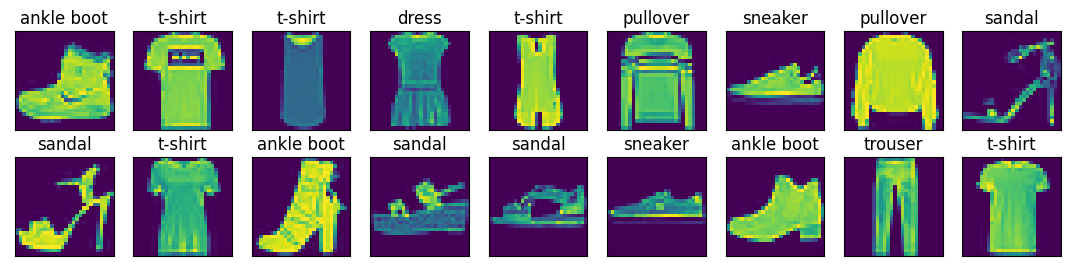

In [8]:
X, y = next(iter(data.DataLoader(mnist_train, batch_size=18)))
show_images(X.reshape(18, 28, 28), 2, 9, titles=get_fashion_mnist_labels(y));

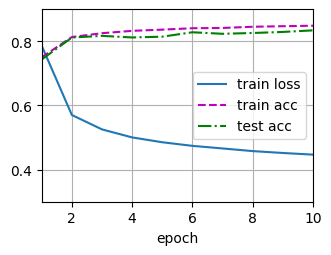

In [19]:
# 读取训练与测试数据
batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size)

# 模型
num_inputs = 28 * 28
num_outputs = 10
lr = 0.1
num_epochs = 10

W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

train(net, train_iter, test_iter, cross_entropy, num_epochs, updater)




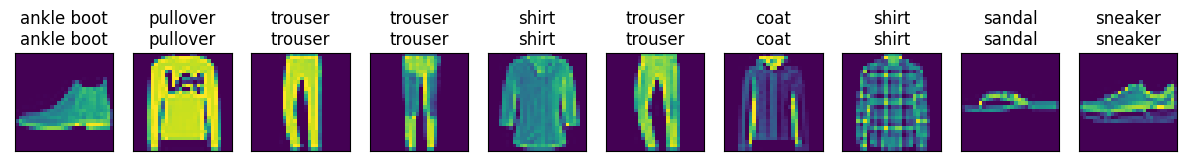

In [24]:
# 预测
predict(net, test_iter, n=10)

torch.Size([256, 784])

In [11]:
# 测试读取时间
batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size)

start = time.perf_counter()
for X, y in train_iter:
    continue
end = time.perf_counter()
f'{end - start:.2f} sec'

'6.56 sec'

In [4]:
x = torch.tensor(0.000, requires_grad=True)
y = torch.relu(x)
y.backward()

print(f"ReLU在0处的梯度: {x.grad}")  # tensor(0.)

ReLU在0处的梯度: 0.0


In [5]:
import time
import torch

def try_gpu(i=0):  #@save
    """如果存在，则返回gpu(i)，否则返回cpu()"""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')


n = 2000
A = torch.randn(n,n)
B = torch.randn(n,n)
startTime1=time.time()
for i in range(100):
    C = torch.matmul(A,B)
endTime1=time.time()


A = torch.randn(n,n,device=try_gpu())
B = torch.randn(n,n,device=try_gpu())
startTime2=time.time()
for i in range(100):
    C = torch.matmul(A,B)
endTime2=time.time()

print('cpu计算总时长:', round((endTime1 - startTime1)*1000, 2),'ms')
print('gpu计算总时长:', round((endTime2 - startTime2)*1000, 2),'ms')

cpu计算总时长: 8228.71 ms
gpu计算总时长: 10.08 ms


In [7]:
a = torch.tensor([1,1,1])
b = torch.tensor([1,1,1])
print(a+b)

a = [1,1,1]
b = [1,1,1]
print(a+b)

a = (1)
b = (1)
print(a+b)

a = (1,)
b = (1,)
print(a+b)

tensor([2, 2, 2])
[1, 1, 1, 1, 1, 1]
2
(1, 1)
